<a href="https://colab.research.google.com/github/RayCharles8/ML-Project/blob/main/Tabular_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Mount Colab to Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

BASE_DIR  = '/content/drive/MyDrive/IML Project'
DATA_PATH = os.path.join(BASE_DIR, 'Dataset.csv')

print("Dataset path:", DATA_PATH)

Dataset path: /content/drive/MyDrive/IML Project/Dataset.csv


Required Libraries

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

from xgboost import XGBClassifier
import shap

np.random.seed(42)

!pip install pysr

from pysr import PySRRegressor
import sympy as sp


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 17.9 MB/s eta 0:00:00
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] WARNING: You have Julia 1.12.6 installed but 1.10.3 - 1.11 is required.
[juliapkg]   It is recommended that you upgrade Julia or install JuliaUp.
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.9 to /root/.julia/environments/pyjuliapkg/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[

Load Data

In [4]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

print("\nLabel distribution:")
print(df['label'].value_counts())

print("\nClass balance:")
print(df['label'].value_counts(normalize=True).round(3))

# Remove duplicates
df = df.drop_duplicates()

print("\nAfter removing duplicates:", df.shape)

Shape: (9668, 17)

Columns:
 ['mp_material_id', 'mp_formula', 'spacegroup', 'spacegroup_number', 'number of atoms', 'Band Gap', 'a', 'b', 'c', 'alpha', 'beta', 'gamma', 'Z', 'electronegativity', 'Topological Label', 'label', 'cif']

Label distribution:
label
0    5198
1    4470
Name: count, dtype: int64

Class balance:
label
0    0.538
1    0.462
Name: proportion, dtype: float64

After removing duplicates: (9668, 17)


###Feature Engineering

In [5]:
FEATURES = [
    'spacegroup_number',
    'spacegroup',
    'number of atoms',
    'Band Gap',
    'a', 'b', 'c',
    'alpha', 'beta', 'gamma',
    'Z',
    'electronegativity'
]

TARGET = 'label'

df_model = df[FEATURES + [TARGET]].dropna().copy()

###Encode categorical features

In [6]:
le = LabelEncoder()
df_model['spacegroup'] = le.fit_transform(df_model['spacegroup'].astype(str))

X = df_model[FEATURES]
y = df_model[TARGET]

print("Feature matrix:", X.shape)
print("Target:", y.shape)

Feature matrix: (9668, 12)
Target: (9668,)


###Stratified Split of Data (70% 15% 15%)

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

for name, yy in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"{name}: {len(yy)} samples | TI ratio: {yy.mean():.3f}")

Train: 6767 samples | TI ratio: 0.462
Val: 1450 samples | TI ratio: 0.462
Test: 1451 samples | TI ratio: 0.462


####Random Forest Training

In [8]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=3,
    min_samples_split=8,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=3, min_samples_split=8,
                       n_estimators=500, n_jobs=-1, random_state=42)

In [9]:

# Evaluation

def evaluate_model(model, X_data, y_true, name="Set"):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:,1]


    print(f"\n{name} Performance")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print(classification_report(y_true, y_pred))

    return y_prob

In [10]:
print("\nRANDOM FOREST")

rf_train_prob = evaluate_model(rf, X_train, y_train, "Train")
rf_val_prob   = evaluate_model(rf, X_val, y_val, "Validation")
rf_test_prob  = evaluate_model(rf, X_test, y_test, "Test")


RANDOM FOREST

Train Performance
Accuracy: 0.9358652283138762
F1-score: 0.9317180616740088
ROC-AUC: 0.9903217888798875
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      3638
           1       0.92      0.95      0.93      3129

    accuracy                           0.94      6767
   macro avg       0.94      0.94      0.94      6767
weighted avg       0.94      0.94      0.94      6767


Validation Performance
Accuracy: 0.8510344827586207
F1-score: 0.8409425625920471
ROC-AUC: 0.9248737083811711
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       780
           1       0.83      0.85      0.84       670

    accuracy                           0.85      1450
   macro avg       0.85      0.85      0.85      1450
weighted avg       0.85      0.85      0.85      1450


Test Performance
Accuracy: 0.870434183321847
F1-score: 0.8607407407407407
ROC-AUC: 0.9368527647216172
             

RF Confunsion Matrix

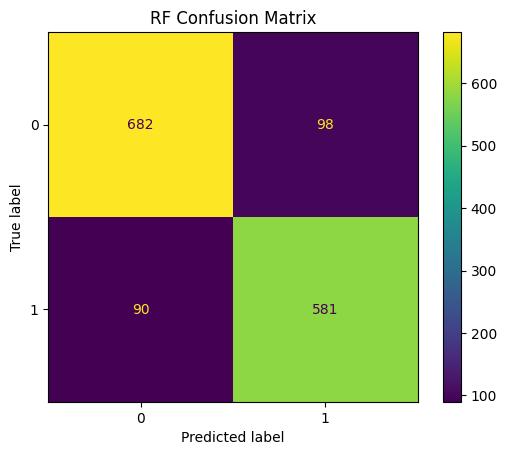

In [11]:
cm = confusion_matrix(y_test, rf.predict(X_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("RF Confusion Matrix")
plt.show()

###XGBoost Training

In [12]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=5,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1.5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [13]:
print("\nXGBoost")

xgb_train_prob = evaluate_model(xgb_model, X_train, y_train, "Train")
xgb_val_prob   = evaluate_model(xgb_model, X_val, y_val, "Validation")
xgb_test_prob  = evaluate_model(xgb_model, X_test, y_test, "Test")


XGBoost

Train Performance
Accuracy: 0.900990099009901
F1-score: 0.8948524795982423
ROC-AUC: 0.9666908160742814
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      3638
           1       0.88      0.91      0.89      3129

    accuracy                           0.90      6767
   macro avg       0.90      0.90      0.90      6767
weighted avg       0.90      0.90      0.90      6767


Validation Performance
Accuracy: 0.8517241379310345
F1-score: 0.8427212874908558
ROC-AUC: 0.9264016456180635
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       780
           1       0.83      0.86      0.84       670

    accuracy                           0.85      1450
   macro avg       0.85      0.85      0.85      1450
weighted avg       0.85      0.85      0.85      1450


Test Performance
Accuracy: 0.8738800827015851
F1-score: 0.8641425389755011
ROC-AUC: 0.9373399824219495
              preci

XGB Confunsion Matrix

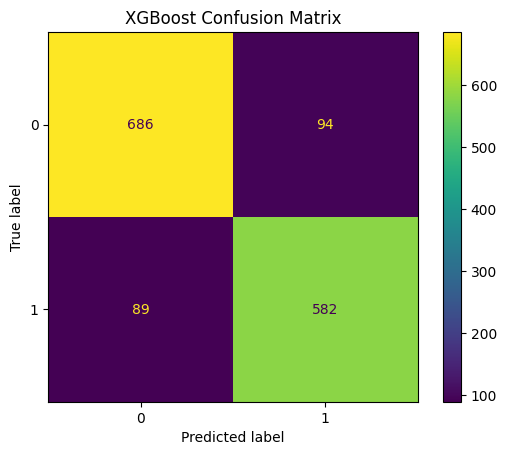

In [14]:
cm = confusion_matrix(y_test, xgb_model.predict(X_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

###RF & XGB ROC CURVES

<Figure size 700x600 with 0 Axes>

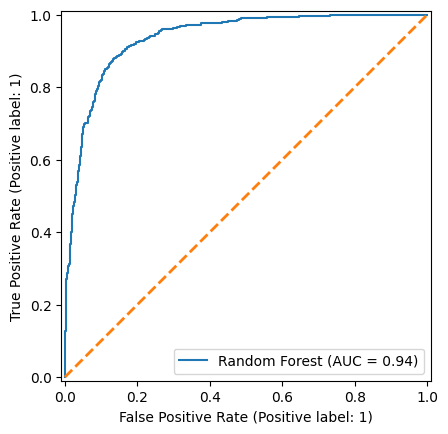

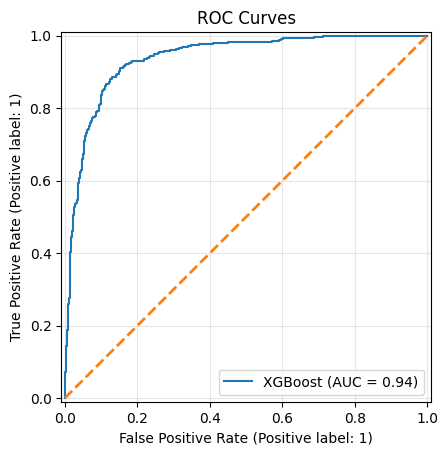

In [15]:
# RF & XGB ROC CURVES
plt.figure(figsize=(7,6))

# Random Forest ROC
RocCurveDisplay.from_predictions(
    y_test,
    rf_test_prob,
    name="Random Forest"
)
# Diagonal random-classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2
)

# XGBoost ROC
RocCurveDisplay.from_predictions(
    y_test,
    xgb_test_prob,
    name="XGBoost"
)

# Diagonal random-classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2
)

plt.title("ROC Curves")
plt.grid(alpha=0.3)

plt.show()

# Scatter PLOTS

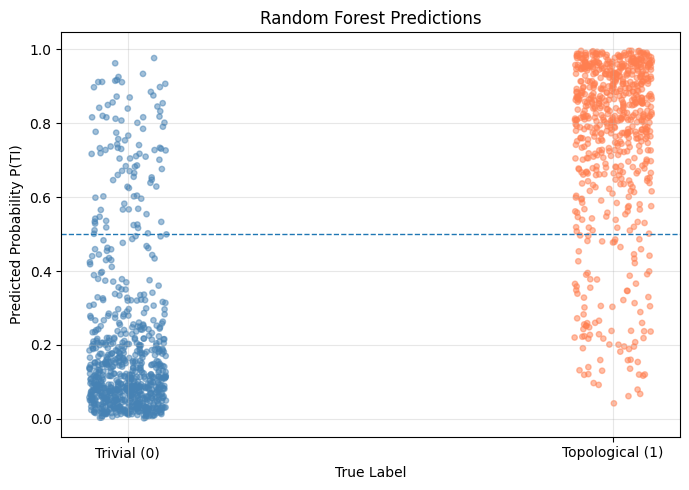

In [16]:
# RF SCATTER PLOT

plt.figure(figsize=(7,5))

# jitter improves visibility
jitter_rf = np.random.uniform(-0.08, 0.08, size=len(y_test))

colors_rf = [
    'steelblue' if l == 0 else 'coral'
    for l in y_test
]

plt.scatter(
    y_test + jitter_rf,
    rf_test_prob,
    c=colors_rf,
    alpha=0.5,
    s=15
)

# decision threshold
plt.axhline(
    0.5,
    linestyle='--',
    linewidth=1
)

plt.xticks(
    [0, 1],
    ['Trivial (0)', 'Topological (1)']
)

plt.xlabel("True Label")
plt.ylabel("Predicted Probability P(TI)")
plt.title("Random Forest Predictions")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

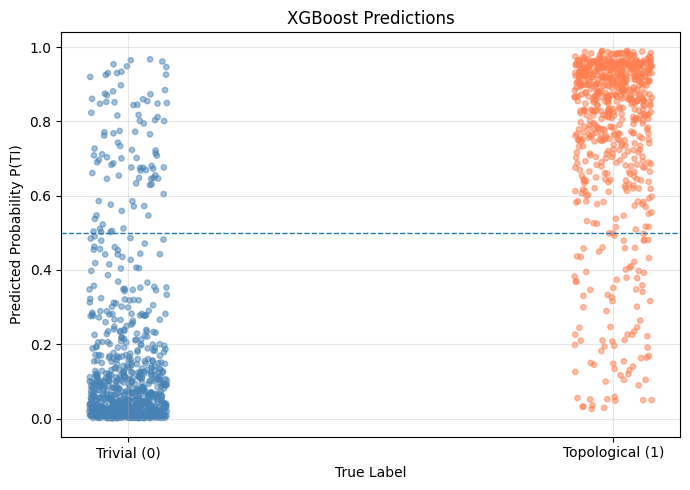

In [17]:
# XGBOOST SCATTER PLOT

plt.figure(figsize=(7,5))

jitter_xgb = np.random.uniform(-0.08, 0.08, size=len(y_test))

colors_xgb = [
    'steelblue' if l == 0 else 'coral'
    for l in y_test
]

plt.scatter(
    y_test + jitter_xgb,
    xgb_test_prob,
    c=colors_xgb,
    alpha=0.5,
    s=15
)

plt.axhline(
    0.5,
    linestyle='--',
    linewidth=1
)

plt.xticks(
    [0, 1],
    ['Trivial (0)', 'Topological (1)']
)

plt.xlabel("True Label")
plt.ylabel("Predicted Probability P(TI)")
plt.title("XGBoost Predictions")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

###SHAP INTERPRETABILITY

In [18]:
#RF
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)

In [19]:
#XGB
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

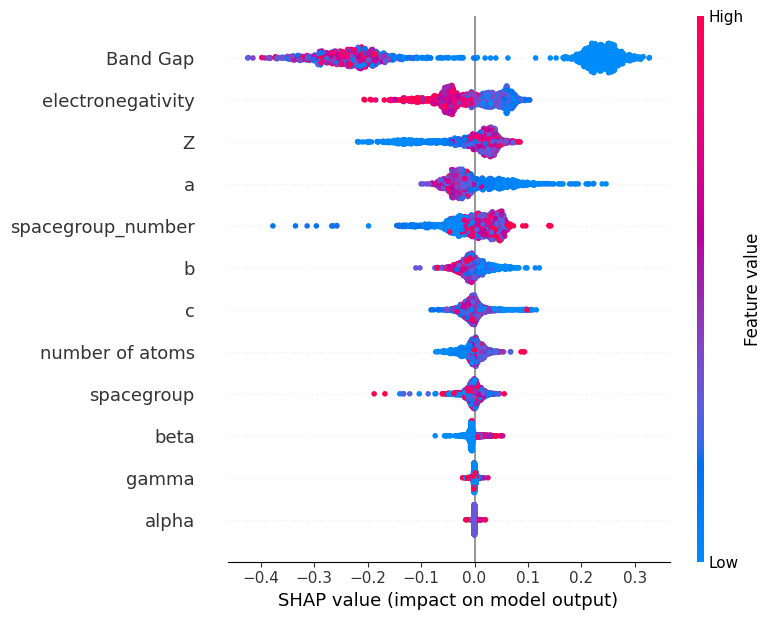

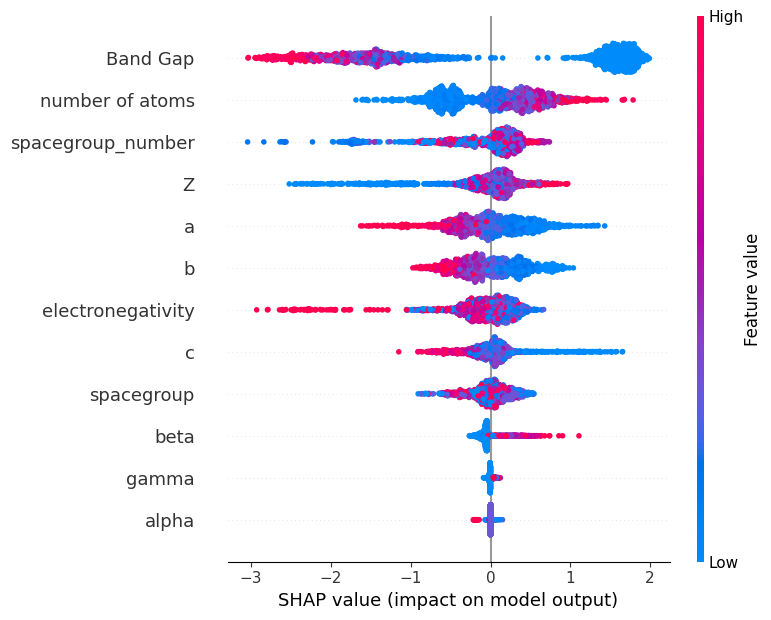

In [20]:
#Beeswarm Plot
shap.summary_plot(shap_values_rf[:, :, 1], X_test)
shap.summary_plot(shap_values_xgb, X_test)

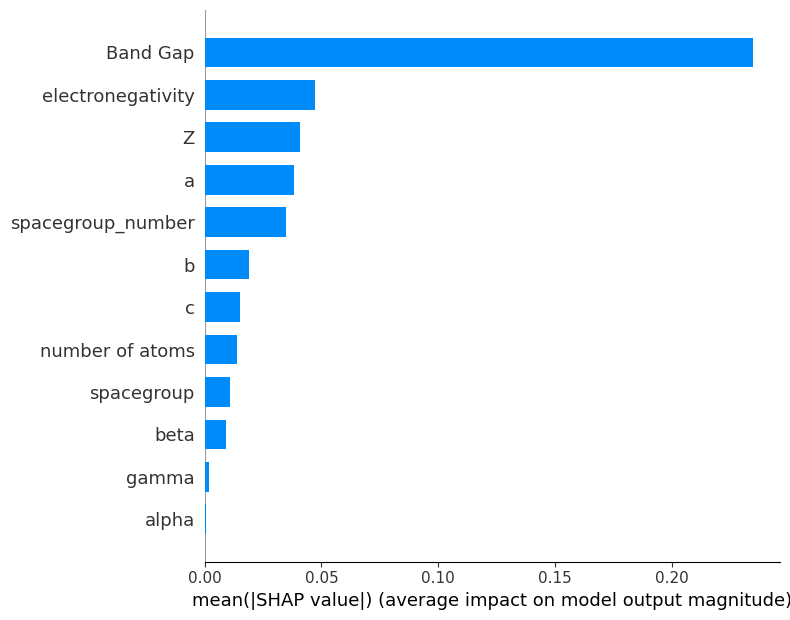

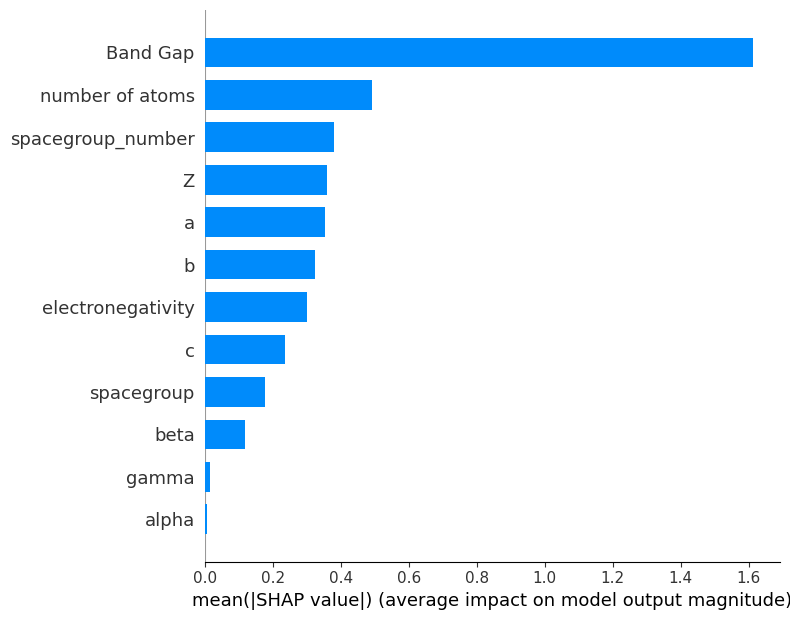

In [21]:
#Bar PLot
shap.summary_plot(shap_values_rf[:, :, 1], X_test, plot_type="bar")
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar")

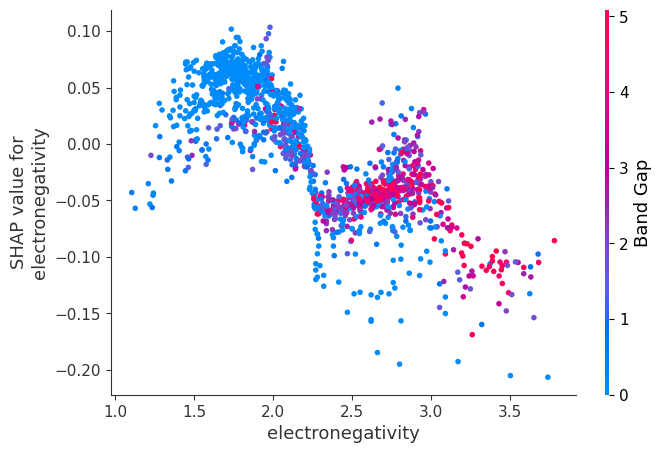

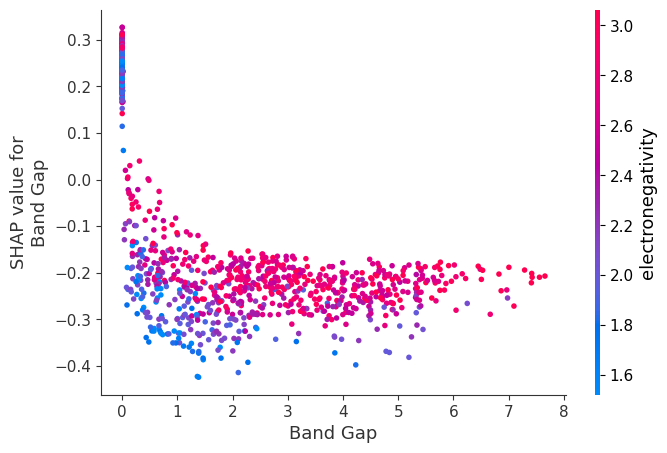

In [22]:
#Dependance plots
import numpy as np

# Calculate feature importance for the positive class (index 1) across all samples
rf_importance = np.abs(shap_values_rf[:, :, 1]).mean(axis=0)
top_features = np.argsort(rf_importance)[-2:]

for i in top_features:
    # Use SHAP values for the positive class (index 1) for all samples
    shap.dependence_plot(X.columns[i], shap_values_rf[:, :, 1], X_test)

<Figure size 600x500 with 0 Axes>

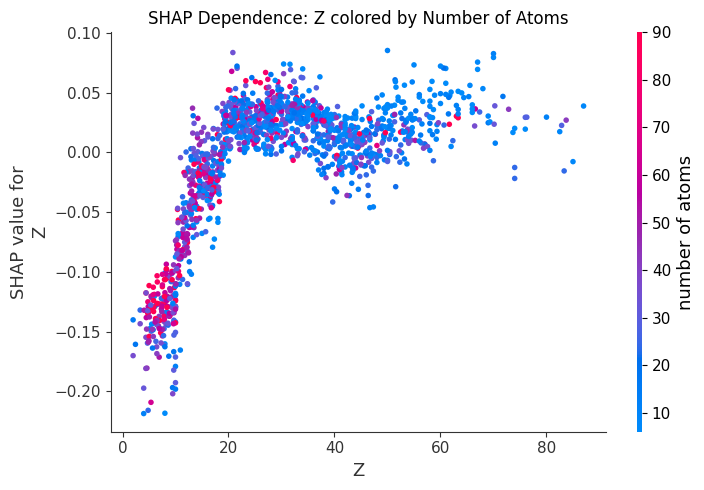

In [23]:

plt.figure(figsize=(6,5))

shap.dependence_plot(
    'Z',
    shap_values_rf[:, :, 1],
    X_test,
    interaction_index='number of atoms',
    show=False
)

plt.title("SHAP Dependence: Z colored by Number of Atoms")
plt.tight_layout()
plt.show()

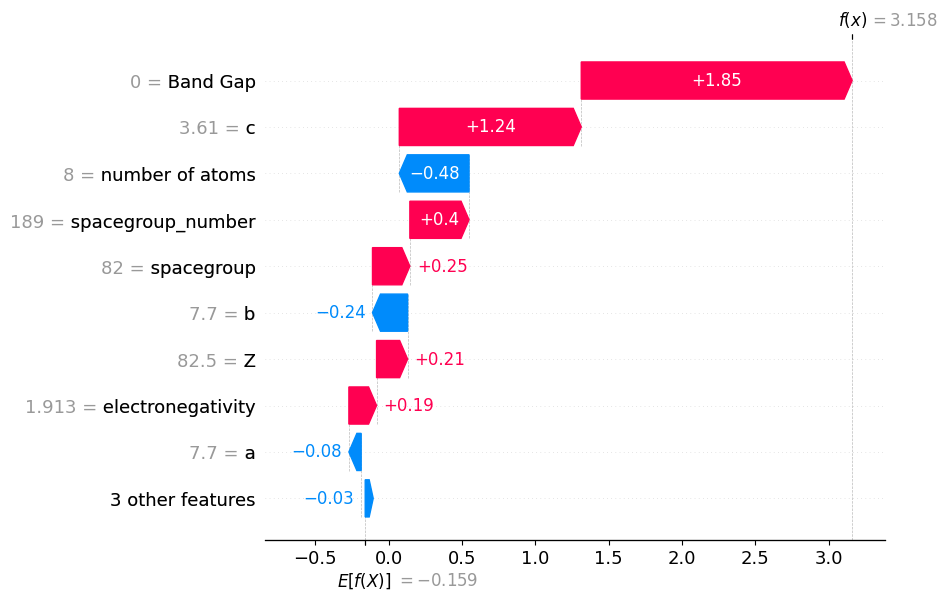

In [24]:
#Waterfall PLot
shap.plots.waterfall(shap.Explanation(
    values=shap_values_xgb[0],
    base_values=explainer_xgb.expected_value,
    data=X_test.iloc[0]
))

In [25]:
#Force PLot
shap.initjs()
shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[0],
    X_test.iloc[0]
)

<Figure size 600x500 with 0 Axes>

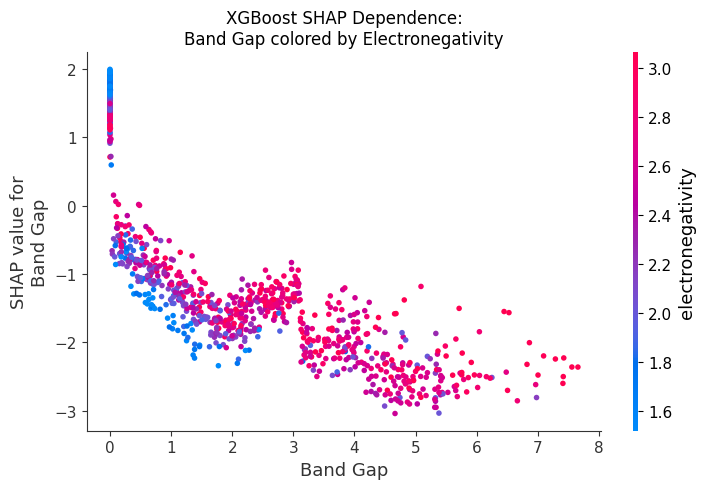

In [26]:

# XGBOOST SHAP DEPENDENCE
# Band Gap vs SHAP(Band Gap)
# colored by Electronegativity
plt.figure(figsize=(6,5))

shap.dependence_plot(
    "Band Gap",
    shap_values_xgb,
    X_test,
    interaction_index="electronegativity",
    show=False
)

plt.title(
    "XGBoost SHAP Dependence:\nBand Gap colored by Electronegativity"
)

plt.tight_layout()

plt.show()

<Figure size 600x500 with 0 Axes>

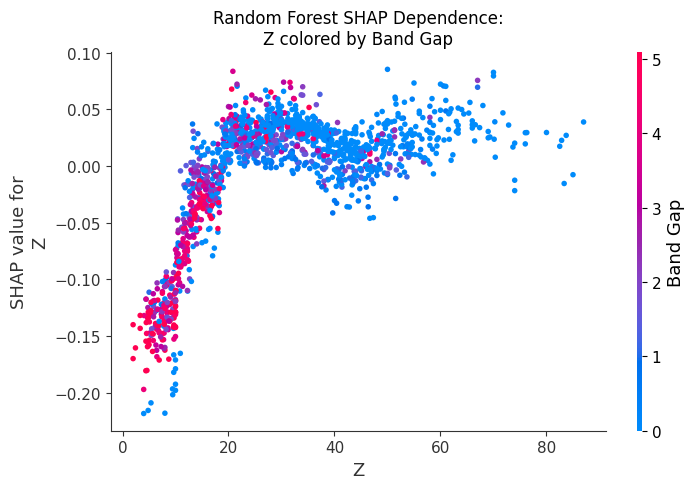

In [27]:

# SHAP DEPENDENCE PLOTS
# RANDOM FOREST
# Z dependence colored by Band Gap
plt.figure(figsize=(6,5))

shap.dependence_plot(
    "Z",
    shap_values_rf[:, :, 1],
    X_test,
    interaction_index="Band Gap",
    show=False
)

plt.title(
    "Random Forest SHAP Dependence:\nZ colored by Band Gap"
)

plt.tight_layout()
plt.show()


<Figure size 600x500 with 0 Axes>

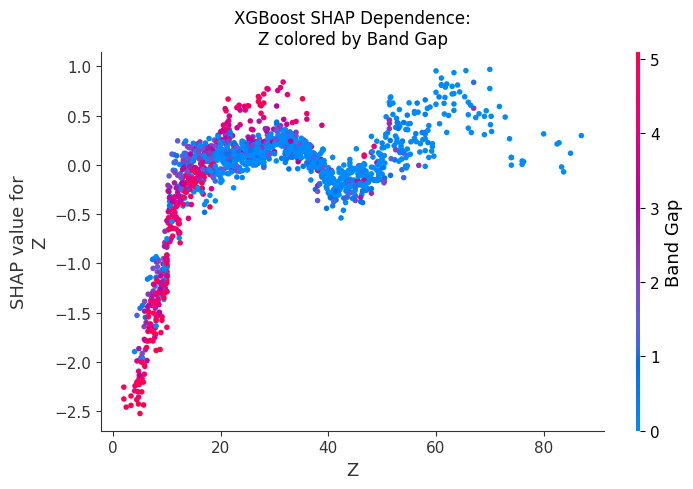

In [28]:
# XGBOOST
# Z dependence colored by Band Gap

plt.figure(figsize=(6,5))

shap.dependence_plot(
    "Z",
    shap_values_xgb,
    X_test,
    interaction_index="Band Gap",
    show=False
)

plt.title(
    "XGBoost SHAP Dependence:\nZ colored by Band Gap"
)

plt.tight_layout()
plt.show()

# PySR

In [29]:
# SYMBOLIC REGRESSION WITH PySR

# TOP FEATURES

TOP_FEATURES = [
    'Band Gap',
    'electronegativity',
    'Z',
    'spacegroup_number',
    'number of atoms',
    'a',
]

X_sr_train = X_train[TOP_FEATURES].copy()
X_sr_val   = X_val[TOP_FEATURES].copy()
X_sr_test  = X_test[TOP_FEATURES].copy()

y_sr_train = y_train.astype(float).values
y_sr_val   = y_val.astype(float).values
y_sr_test  = y_test.astype(float).values

print("PySR Training Shape :", X_sr_train.shape)
print("PySR Validation Shape:", X_sr_val.shape)
print("PySR Test Shape     :", X_sr_test.shape)


# BINARY CROSS-ENTROPY LOSS

BCE_LOSS_JULIA = """
function my_loss(prediction, target)
    p = 1.0f0 / (1.0f0 + exp(-prediction))
    p = clamp(p, 1.0f-7, 1.0f0 - 1.0f-7)
    return -(target * log(p) + (1.0f0 - target) * log(1.0f0 - p))
end
"""


# CONFIGURE PySR

pysr_model = PySRRegressor(

    # OPERATORS

    binary_operators=[
        "+",
        "-",
        "*",
        "/",
    ],

    unary_operators=[
        "square(x) = x^2",
        "cube(x) = x^3",
        "exp",
        "log_safe(x) = log(abs(x) + 1.0f-8)",
        "tanh",
    ],

    # REQUIRED FIX
    extra_sympy_mappings={
        "square": lambda x: x**2,
        "cube": lambda x: x**3,
        "log_safe": lambda x: sp.log(sp.Abs(x) + 1e-8),
    },

    # SEARCH COMPLEXITY

    maxsize=25,
    parsimony=0.003,

    complexity_of_operators={
        "square": 2,
        "cube": 3,
        "exp": 3,
        "log_safe": 3,
        "tanh": 3,
    },

    # LARGE SEARCH

    niterations=100,

    populations=20,
    population_size=40,
    ncycles_per_iteration=500,

    # OBJECTIVE

    elementwise_loss=BCE_LOSS_JULIA,
    loss_scale="linear",

    # MODEL SELECTION

    model_selection="best",

    # FEATURE SELECTION

    select_k_features=6,

    # EARLY STOPPING

    early_stop_condition=(
        "f(loss, complexity) = (loss < 0.35) && (complexity < 18)"
    ),

    # PERFORMANCE

    parallelism="multithreading",

    # REPRODUCIBILITY

    random_state=42,

    # OUTPUT

    verbosity=1,
    progress=True,
    print_precision=5,
)

print("\nPySR model configured.")

PySR Training Shape : (6767, 6)
PySR Validation Shape: (1450, 6)
PySR Test Shape     : (1451, 6)

PySR model configured.


In [30]:
# TRAIN PySR
print("\nTraining PySR model")

pysr_model.fit(
    X_sr_train,
    y_sr_train,
    variable_names=[
        "Band_Gap",
        "electronegativity",
        "Z",
        "spacegroup_number",
        "number_of_atoms",
        "a",
    ]
)


Training PySR model


Using features ['Band_Gap' 'electronegativity' 'Z' 'spacegroup_number' 'number_of_atoms'
 'a']
INFO:pysr.sr:Using features ['Band_Gap' 'electronegativity' 'Z' 'spacegroup_number' 'number_of_atoms'
 'a']
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
[ Info: Started!


Streaming output truncated to the last 5000 lines.
21          4.466e-01  y = log_safe(log_safe(Band_Gap * log_safe(-1.07 / log_safe(electroneg...
                           ativity)))) - (electronegativity - 0.45181)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.940e+03
Progress: 585 / 2000 total iterations (29.250%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Equation
1           6.903e-01  y = -0.15192
3           5.075e-01  y = 0.82339 - Band_Gap
5           5.071e-01  y = (Band_Gap * -1.0722) - -0.86965
7           4.964e-01  y = ((Band_Gap * -2.8975) / electronega

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick                                           equation      loss  \
	0                                               -0.15191631  0.690308   
	1                                     0.82339305 - Band_Gap  0.507538   
	2                     (Band_Gap * -1.0712509) - -0.86830837  0.507116   
	3         (Band_Gap + -0.6937725) * (-2.6810482 / electr...  0.492181   
	4           log_safe(-0.28467473 / (Band_Gap + 0.07294896))  0.460590   
	5         ((-0.3151497 / (Band_Gap + 0.03620066)) * -0.3...  0.456987   
	6         log_safe((-0.08314399 / (Band_Gap + 0.02088915...  0.455119   
	7         log_safe((log_safe(Band_Gap) * 0.1689918) - 0....  0.454773   
	8         log_safe((-0.73099643 / a) + (-0.084409244 / (...  0.451660   
	9         log_safe(log_safe(Band_Gap / square(electroneg...  0.451000   
	10        (log_safe(log_safe(Band_Gap / square(electrone...  0.449378   
	11        log_safe(((log_safe(Band_Gap) / -1.5976884) + ...  0.447936   
	12        log_safe(log_safe(log_safe(electronegativity /...  0.445908   
	13        log_safe(log_safe((Band_Gap * -0.7961601) * lo...  0.444904   
	14  >>>>  (log_safe(log_safe((log_safe(log_safe(1.071222...  0.440705   
	
	    complexity  
	0            1  
	1            3  
	2            5  
	3            7  
	4            8  
	5            9  
	6           10  
	7           11  
	8           12  
	9           13  
	10          15  
	11          17  
	12          18  
	13          23  
	14          25  
]

  - outputs/20260607_124806_V6gtux/hall_of_fame.csv


In [40]:
print(pysr_model.equations_.columns)

Index(['complexity', 'loss', 'equation', 'sympy_format', 'lambda_format'], dtype='object')


In [41]:
# BEST EQUATION = LOWEST LOSS

best_idx = pysr_model.equations_["loss"].idxmin()
best_equation = pysr_model.equations_.iloc[best_idx]

print("\nBEST EQUATION\n")
print(best_equation["equation"])

print("\nComplexity:", best_equation["complexity"])
print("Loss:", best_equation["loss"])


BEST EQUATION

(log_safe(log_safe((log_safe(log_safe(1.0712228 / electronegativity)) * Band_Gap) * (a * 0.10390111))) - electronegativity) - -0.36928958

Complexity: 25
Loss: 0.44070494


In [42]:
model_selection="best"

In [43]:
print(pysr_model.get_best())

complexity                                                      25
loss                                                      0.440705
equation         (log_safe(log_safe((log_safe(log_safe(1.071222...
sympy_format     -electronegativity + log(Abs(log(0.10390111*Ab...
lambda_format    PySRFunction(X=>-electronegativity + log(Abs(l...
Name: 14, dtype: object


In [44]:
best_equation = pysr_model.get_best()
print(best_equation)

complexity                                                      25
loss                                                      0.440705
equation         (log_safe(log_safe((log_safe(log_safe(1.071222...
sympy_format     -electronegativity + log(Abs(log(0.10390111*Ab...
lambda_format    PySRFunction(X=>-electronegativity + log(Abs(l...
Name: 14, dtype: object


In [45]:
print("\nColumns:")
print(pysr_model.equations_.columns)

print("\nFirst few rows:")
display(pysr_model.equations_.head())


Columns:
Index(['complexity', 'loss', 'equation', 'sympy_format', 'lambda_format'], dtype='object')

First few rows:


,complexity,loss,equation,sympy_format,lambda_format
0,1,0.690308,-0.15191631,-0.151916310000000,PySRFunction(X=>-0.151916310000000)
1,3,0.507538,0.82339305 - Band_Gap,0.82339305 - Band_Gap,PySRFunction(X=>0.82339305 - Band_Gap)
2,5,0.507116,(Band_Gap * -1.0712509) - -0.86830837,Band_Gap*(-1.0712509) - 1*(-0.86830837),PySRFunction(X=>Band_Gap*(-1.0712509) - 1*(-0....
3,7,0.492181,(Band_Gap + -0.6937725) * (-2.6810482 / electr...,(Band_Gap - 0.6937725)*(-2.6810482)/electroneg...,PySRFunction(X=>(Band_Gap - 0.6937725)*(-2.681...
4,8,0.460590,log_safe(-0.28467473 / (Band_Gap + 0.07294896)),log(1.0e-8 + 0.28467473/Abs(Band_Gap + 0.07294...,PySRFunction(X=>log(1.0e-8 + 0.28467473/Abs(Ba...


In [46]:
pysr_model.equations_[["complexity","loss","equation"]]

,complexity,loss,equation
0,1,0.690308,-0.15191631
1,3,0.507538,0.82339305 - Band_Gap
2,5,0.507116,(Band_Gap * -1.0712509) - -0.86830837
3,7,0.492181,(Band_Gap + -0.6937725) * (-2.6810482 / electr...
4,8,0.460590,log_safe(-0.28467473 / (Band_Gap + 0.07294896))
5,9,0.456987,((-0.3151497 / (Band_Gap + 0.03620066)) * -0.3...
6,10,0.455119,log_safe((-0.08314399 / (Band_Gap + 0.02088915...
7,11,0.454773,log_safe((log_safe(Band_Gap) * 0.1689918) - 0....
8,12,0.451660,log_safe((-0.73099643 / a) + (-0.084409244 / (...
9,13,0.451000,log_safe(log_safe(Band_Gap / square(electroneg...


In [38]:
# SYMPY REPRESENTATION
print(pysr_model.sympy())

-electronegativity + log(Abs(log(0.10390111*Abs(Band_Gap*a*log(Abs(log(1.0e-8 + 1.0712228/Abs(electronegativity))) + 1.0e-8)) + 1.0e-8)) + 1.0e-8) - 1*(-0.36928958)


In [39]:
# LATEX REPRESENTATION

print(pysr_model.latex())

- electronegativity + \log{\left(\left|{\log{\left(0.104 \left|{Band_{Gap} a \log{\left(\left|{\log{\left(1.00 \cdot 10^{-8} + \frac{1.07}{\left|{electronegativity}\right|} \right)}}\right| + 1.00 \cdot 10^{-8} \right)}}\right| + 1.00 \cdot 10^{-8} \right)}}\right| + 1.00 \cdot 10^{-8} \right)} - -0.369
